# Week 3 — LBP Baseline Texture Deviation Detection
Builds a multi-radius uniform-LBP "normal texture" model per fabric type from Week 2's defect-free patches, scores deviation on defect patches, thresholds it into a predicted mask, and reports rough IoU / precision / recall / F1 on a few images.

**SETUP**  
Mount Drive and import libraries.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random

from skimage.feature import local_binary_pattern
from skimage.filters import threshold_otsu


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**LOAD WEEK 2 PATCH DATASET**  
Point at the patch folders already created in Week 2 (no re-processing here).

In [3]:
PATCHED_DIR = Path("/content/drive/MyDrive/ECE501/processed_patches")

PATCH_IMAGE_DIR = PATCHED_DIR / "images"
PATCH_MASK_DIR = PATCHED_DIR / "masks"
NODEFECT_PATCH_DIR = PATCHED_DIR / "nodefect_images"

defect_patch_files = sorted(PATCH_IMAGE_DIR.glob("*.png"))
nodefect_patch_files = sorted(NODEFECT_PATCH_DIR.glob("*.png"))

print("=" * 60)
print("PATCH DATASET LOADED")
print("=" * 60)

print(f"Defect patches       : {len(defect_patch_files)}")
print(f"Defect-free patches  : {len(nodefect_patch_files)}")


PATCH DATASET LOADED
Defect patches       : 3222
Defect-free patches  : 4371


**FABRIC TYPE FROM FILENAME**  
Same rule as Week 2 — fabric type is the numeric prefix before the first underscore.

In [4]:
def get_fabric_type(stem):
    return stem.split("_")[0]

nodefect_fabric_counts = {}
for file in nodefect_patch_files:
    fabric_type = get_fabric_type(file.stem)
    nodefect_fabric_counts[fabric_type] = nodefect_fabric_counts.get(fabric_type, 0) + 1

print("=" * 60)
print("DEFECT-FREE PATCHES PER FABRIC TYPE")
print("=" * 60)

for fabric_type, count in sorted(nodefect_fabric_counts.items()):
    print(f"Fabric type {fabric_type} : {count} patches")


DEFECT-FREE PATCHES PER FABRIC TYPE
Fabric type 0001 : 217 patches
Fabric type 0002 : 217 patches
Fabric type 0003 : 217 patches
Fabric type 0004 : 217 patches
Fabric type 0005 : 217 patches
Fabric type 0006 : 217 patches
Fabric type 0007 : 217 patches
Fabric type 0008 : 217 patches
Fabric type 0009 : 217 patches
Fabric type 0010 : 217 patches
Fabric type 0011 : 217 patches
Fabric type 0012 : 217 patches
Fabric type 0013 : 217 patches
Fabric type 0014 : 217 patches
Fabric type 0015 : 217 patches
Fabric type 0016 : 217 patches
Fabric type 0017 : 217 patches
Fabric type 0018 : 248 patches
Fabric type 0019 : 217 patches
Fabric type 0020 : 217 patches


**MULTI-RADIUS UNIFORM LBP**  
LBP histogram at several radii, concatenated into one feature vector. Window size here is reused for the reference model and the deviation map so both are computed at the same scale.

In [5]:
LBP_RADII = [1, 2, 3]
LBP_METHOD = "uniform"
WINDOW_SIZE = 32
WINDOW_STRIDE = 16

def lbp_histogram(gray_patch, radii=LBP_RADII, method=LBP_METHOD):
    hist_all = []

    for radius in radii:
        n_points = 8 * radius
        lbp = local_binary_pattern(gray_patch, n_points, radius, method)
        n_bins = n_points + 2

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=n_bins,
            range=(0, n_bins),
            density=True
        )
        hist_all.append(hist)

    return np.concatenate(hist_all)


**SANITY CHECK**  
Visualize LBP on a sample patch that has real texture (skips flat/blank patches).

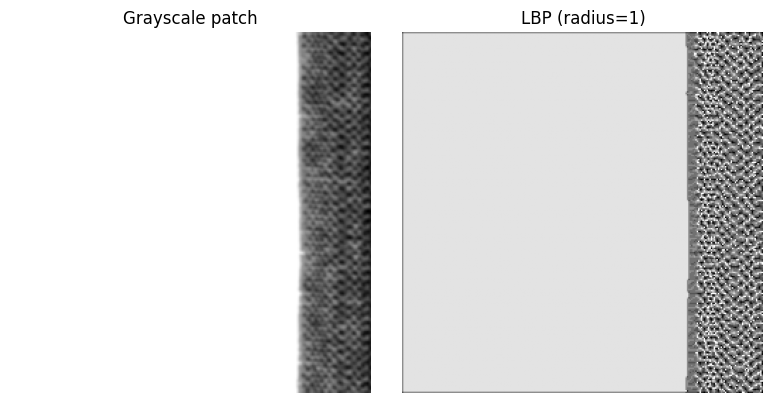

In [6]:
VARIANCE_THRESHOLD = 5.0

sample_file = next(
    (f for f in nodefect_patch_files
     if cv2.imread(str(f), cv2.IMREAD_GRAYSCALE).std() > VARIANCE_THRESHOLD),
    nodefect_patch_files[0]
)

sample_gray = cv2.imread(str(sample_file), cv2.IMREAD_GRAYSCALE)
sample_lbp = local_binary_pattern(sample_gray, 8, 1, LBP_METHOD)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_gray, cmap="gray")
plt.title("Grayscale patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_lbp, cmap="gray")
plt.title("LBP (radius=1)")
plt.axis("off")

plt.tight_layout()
plt.show()


**NORMAL TEXTURE MODEL**  
Average LBP histogram per fabric type, computed over windows from defect-free patches. Flat/blank windows (no real texture) are skipped so they don't bias the reference.

In [7]:
fabric_hist_sum = {}
fabric_hist_count = {}
skipped_blank_windows = 0

for file in nodefect_patch_files:
    fabric_type = get_fabric_type(file.stem)
    gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)

    if gray is None:
        continue

    h, w = gray.shape

    for y in range(0, h - WINDOW_SIZE + 1, WINDOW_SIZE):
        for x in range(0, w - WINDOW_SIZE + 1, WINDOW_SIZE):
            window = gray[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]

            if window.std() < VARIANCE_THRESHOLD:
                skipped_blank_windows += 1
                continue

            hist = lbp_histogram(window)

            if fabric_type not in fabric_hist_sum:
                fabric_hist_sum[fabric_type] = np.zeros_like(hist)
                fabric_hist_count[fabric_type] = 0

            fabric_hist_sum[fabric_type] += hist
            fabric_hist_count[fabric_type] += 1

normal_texture_model = {
    fabric_type: fabric_hist_sum[fabric_type] / fabric_hist_count[fabric_type]
    for fabric_type in fabric_hist_sum
}

# Fallback reference for any fabric type with no defect-free patches
global_reference_hist = np.mean(list(normal_texture_model.values()), axis=0)

print("=" * 60)
print("NORMAL TEXTURE MODEL BUILT")
print("=" * 60)

print(f"Blank/flat windows skipped (std < {VARIANCE_THRESHOLD}) : {skipped_blank_windows}")
print()

for fabric_type, count in sorted(fabric_hist_count.items()):
    print(f"Fabric type {fabric_type} : reference built from {count} windows")


NORMAL TEXTURE MODEL BUILT
Blank/flat windows skipped (std < 5.0) : 27317

Fabric type 0001 : reference built from 12496 windows
Fabric type 0002 : reference built from 12502 windows
Fabric type 0003 : reference built from 12496 windows
Fabric type 0004 : reference built from 12496 windows
Fabric type 0005 : reference built from 12499 windows
Fabric type 0006 : reference built from 12496 windows
Fabric type 0007 : reference built from 12496 windows
Fabric type 0008 : reference built from 12502 windows
Fabric type 0009 : reference built from 12496 windows
Fabric type 0010 : reference built from 12496 windows
Fabric type 0011 : reference built from 12566 windows
Fabric type 0012 : reference built from 12570 windows
Fabric type 0013 : reference built from 12564 windows
Fabric type 0014 : reference built from 12572 windows
Fabric type 0015 : reference built from 12560 windows
Fabric type 0016 : reference built from 12564 windows
Fabric type 0017 : reference built from 12562 windows
Fabric 

**DEVIATION SCORING**  
Chi-square distance between a window's LBP histogram and its fabric type's reference, and a sliding-window deviation map over a full patch.

In [8]:
def chi_square_distance(hist1, hist2, eps=1e-10):
    return 0.5 * np.sum(((hist1 - hist2) ** 2) / (hist1 + hist2 + eps))

def compute_deviation_map(gray_patch, reference_hist, window_size=WINDOW_SIZE, stride=WINDOW_STRIDE):
    h, w = gray_patch.shape
    deviation_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    for y in range(0, h - window_size + 1, stride):
        for x in range(0, w - window_size + 1, stride):
            window = gray_patch[y:y + window_size, x:x + window_size]
            hist = lbp_histogram(window)
            score = chi_square_distance(hist, reference_hist)

            deviation_map[y:y + window_size, x:x + window_size] += score
            count_map[y:y + window_size, x:x + window_size] += 1

    count_map[count_map == 0] = 1
    return deviation_map / count_map

def deviation_map_to_mask(deviation_map):
    norm_map = (deviation_map - deviation_map.min()) / (deviation_map.max() - deviation_map.min() + 1e-10)
    norm_map_uint8 = (norm_map * 255).astype(np.uint8)

    try:
        thresh = threshold_otsu(norm_map_uint8)
    except ValueError:
        thresh = 128

    binary_mask = (norm_map_uint8 > thresh).astype(np.uint8) * 255
    return binary_mask, norm_map

def confidence_score(deviation_map, binary_mask):
    if np.count_nonzero(binary_mask) == 0:
        return 0.0

    region_vals = deviation_map[binary_mask > 0]
    background_vals = deviation_map[binary_mask == 0]

    if len(background_vals) == 0:
        return 0.0

    return float((region_vals.mean() - background_vals.mean()) / (background_vals.std() + 1e-10))


**EVALUATION METRICS**  
Pixel-level IoU, precision, recall, F1 against the Week 2 ground-truth mask.

In [9]:
def compute_metrics(pred_mask, gt_mask):
    pred = pred_mask > 0
    gt = gt_mask > 0

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, np.logical_not(gt)).sum()
    fn = np.logical_and(np.logical_not(pred), gt).sum()

    iou = tp / (tp + fp + fn + 1e-10)
    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)

    return {"IoU": iou, "Precision": precision, "Recall": recall, "F1": f1}


**RUN BASELINE ON SAMPLE PATCHES**  
Randomly sample a handful of defect-containing patches (seeded for repeatability) and run the full pipeline on each.

In [10]:
random.seed(42)
N_SAMPLES = 10

candidate_patches = []
for file in defect_patch_files:
    mask_path = PATCH_MASK_DIR / file.name
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is not None and np.count_nonzero(mask) > 0:
        candidate_patches.append(file)

N_SAMPLES = min(N_SAMPLES, len(candidate_patches))
sample_patches = sorted(random.sample(candidate_patches, N_SAMPLES))

results = []

for file in sample_patches:
    gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(str(PATCH_MASK_DIR / file.name), cv2.IMREAD_GRAYSCALE)

    fabric_type = get_fabric_type(file.stem)
    reference_hist = normal_texture_model.get(fabric_type, global_reference_hist)

    deviation_map = compute_deviation_map(gray, reference_hist)
    pred_mask, norm_map = deviation_map_to_mask(deviation_map)
    confidence = confidence_score(deviation_map, pred_mask)
    metrics = compute_metrics(pred_mask, gt_mask)

    results.append({
        "file": file.name,
        "fabric_type": fabric_type,
        "confidence": confidence,
        **metrics
    })

results_df = pd.DataFrame(results)

print("=" * 60)
print("BASELINE RESULTS — SAMPLE PATCHES")
print("=" * 60)

print(results_df.round(3).to_string(index=False))


BASELINE RESULTS — SAMPLE PATCHES
                    file fabric_type  confidence   IoU  Precision  Recall    F1
0010_006_02_x2944_y0.png        0010       2.247 0.005      0.005   0.218 0.010
0023_019_02_x1920_y0.png        0023       2.852 0.000      0.000   0.000 0.000
0025_019_02_x2688_y0.png        0025       3.155 0.000      0.000   0.000 0.000
0032_019_02_x3072_y0.png        0032       2.852 0.000      0.000   0.000 0.000
0053_019_03_x1408_y0.png        0053       2.616 0.000      0.000   0.000 0.000
 0058_019_06_x768_y0.png        0058       4.441 0.000      0.000   0.000 0.000
0064_022_00_x1152_y0.png        0064      13.757 0.000      0.000   0.000 0.000
0093_030_01_x1792_y0.png        0093       3.386 0.000      0.000   0.000 0.000
0103_010_03_x1664_y0.png        0103       2.333 0.003      0.003   0.027 0.006
0104_022_03_x1152_y0.png        0104       4.360 0.000      0.000   0.000 0.000


**VISUALIZE EXAMPLES**  
Original patch, deviation map, predicted mask, and ground truth for a few samples.

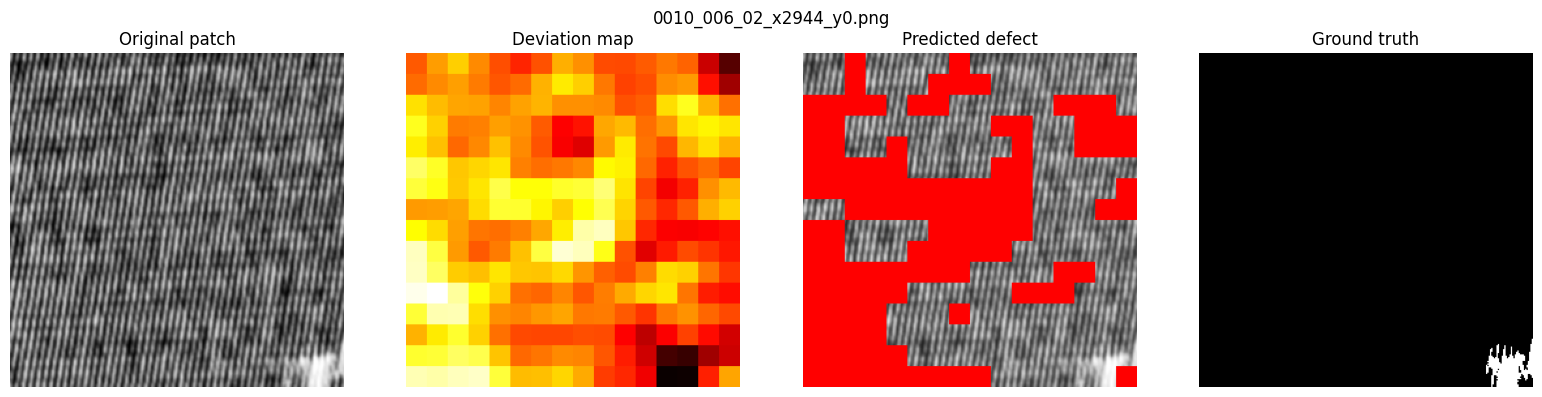

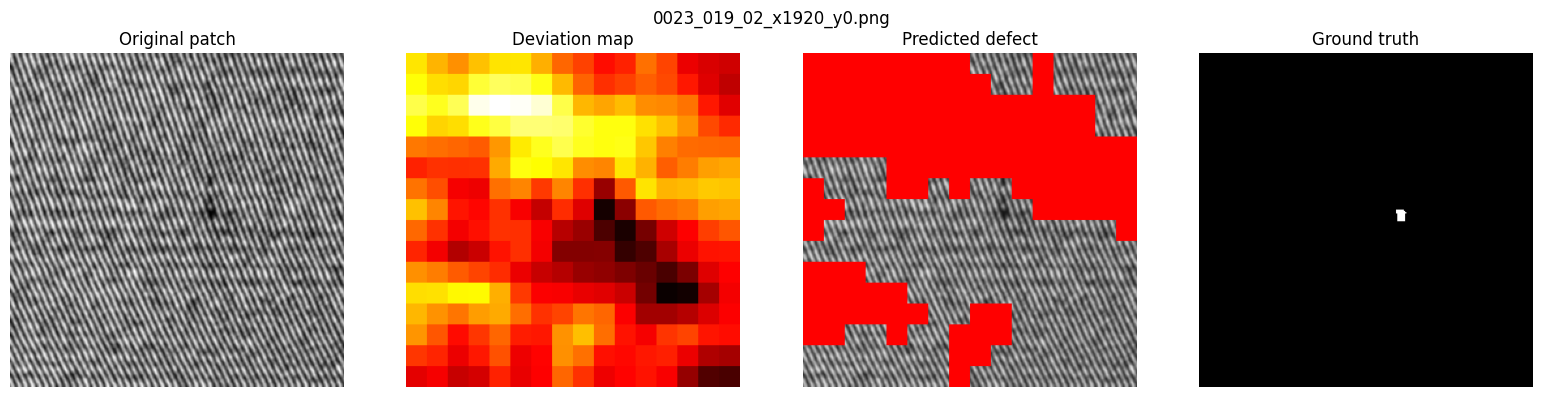

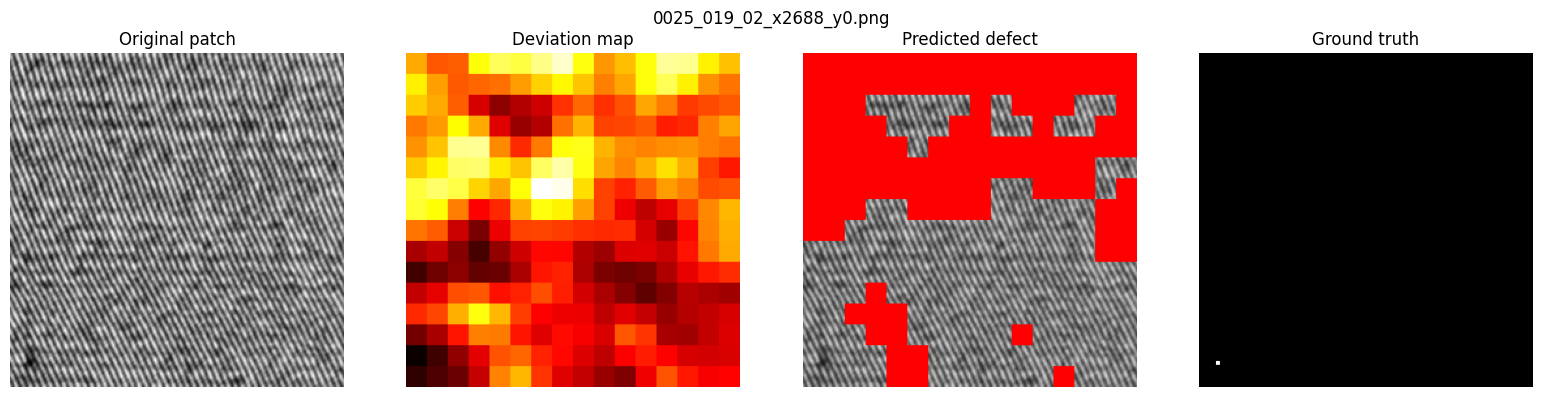

In [11]:
N_SHOW = 3

for file in sample_patches[:N_SHOW]:
    gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(str(PATCH_MASK_DIR / file.name), cv2.IMREAD_GRAYSCALE)

    fabric_type = get_fabric_type(file.stem)
    reference_hist = normal_texture_model.get(fabric_type, global_reference_hist)

    deviation_map = compute_deviation_map(gray, reference_hist)
    pred_mask, norm_map = deviation_map_to_mask(deviation_map)

    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    overlay[pred_mask > 0] = [255, 0, 0]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Original patch")

    axes[1].imshow(norm_map, cmap="hot")
    axes[1].set_title("Deviation map")

    axes[2].imshow(overlay)
    axes[2].set_title("Predicted defect")

    axes[3].imshow(gt_mask, cmap="gray")
    axes[3].set_title("Ground truth")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(file.name)
    plt.tight_layout()
    plt.show()


**WEEK 3 SUMMARY**  
Average metrics across the sample set and a note on scope.

In [12]:
avg_metrics = results_df[["IoU", "Precision", "Recall", "F1"]].mean()

print("=" * 60)
print("WEEK 3 — BASELINE LBP SUMMARY")
print("=" * 60)

print(f"\nSample patches evaluated : {len(results_df)}")
print(f"LBP radii used           : {LBP_RADII}")
print(f"Sliding window           : {WINDOW_SIZE}x{WINDOW_SIZE}, stride {WINDOW_STRIDE}")
print(f"Deviation measure        : chi-square distance")
print(f"Threshold method         : Otsu")

print("\nAverage metrics (sample set):")
print(avg_metrics.round(3).to_string())

print("\nNote: fixed radii and fixed window size for all fabric types — this is the")
print("single-scale baseline. Week 5 compares this against adaptive multi-scale parameters.")


WEEK 3 — BASELINE LBP SUMMARY

Sample patches evaluated : 10
LBP radii used           : [1, 2, 3]
Sliding window           : 32x32, stride 16
Deviation measure        : chi-square distance
Threshold method         : Otsu

Average metrics (sample set):
IoU          0.001
Precision    0.001
Recall       0.024
F1           0.002

Note: fixed radii and fixed window size for all fabric types — this is the
single-scale baseline. Week 5 compares this against adaptive multi-scale parameters.
